e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

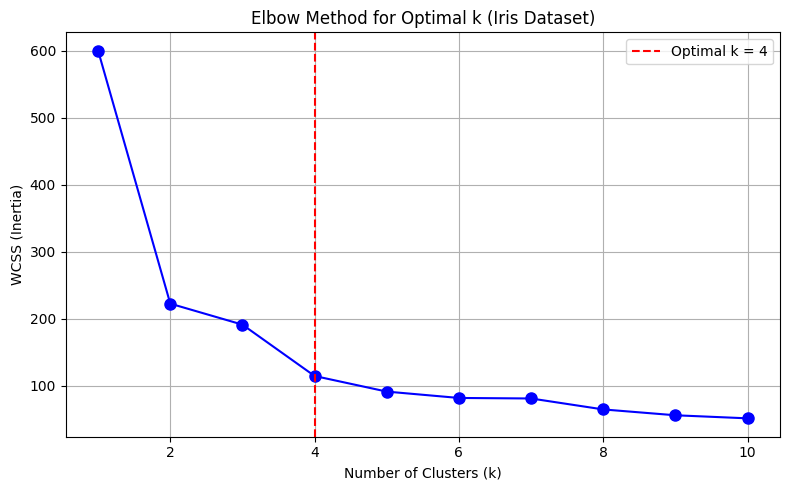

Optimal number of clusters according to the Elbow Method: 4


In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# Step 1: Load and scale the Iris dataset
iris = load_iris()
X = iris.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply K-Means for different values of k
wcss = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # WCSS (inertia), Total squared distance between each point and its cluster centroid.

# The elbow point is the balance between compact clusters and model simplicity. Point where the rate of WCSS decrease sharply slows down.

# Step 3: Use KneeLocator to find the elbow point
knee = KneeLocator(K, wcss, curve='convex', direction='decreasing')
optimal_k = knee.knee

# Step 4: Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, wcss, 'bo-', markersize=8)
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k (Iris Dataset)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5: Output the optimal k
print(f"Optimal number of clusters according to the Elbow Method: {optimal_k}")

e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

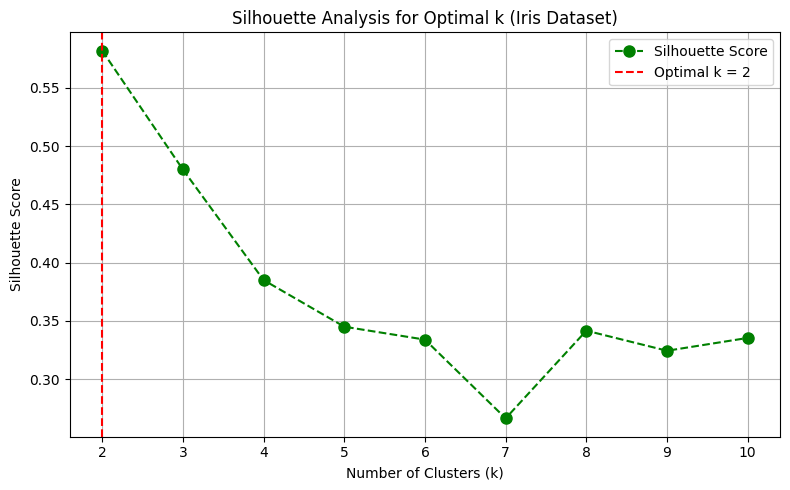

Optimal number of clusters according to Silhouette Score: 2


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Step 1: Load and scale the Iris dataset
iris = load_iris()
X = iris.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply KMeans for different values of k and calculate Silhouette Score
silhouette_scores = []
K = range(2, 11)  # Silhouette score is undefined for k=1

# What is Silhouette score?
# a = average distance to all other points in the same cluster (intra-cluster distance)
# b = average distance to all points in the different cluster (inter-cluster distance)
# The silhouette score for a point is:
# Silhouette = (b-a)/max(a, b)

# +1 → Point is well-clustered and far from others.
# 0  → Point is on the boundary between two clusters. Clusters are overlapping
# –1 → Point is likely in the wrong cluster.

# Then average over all points to get the overall score

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Step 3: Find the best k (maximum silhouette score)
best_k = K[silhouette_scores.index(max(silhouette_scores))]

# Step 4: Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, 'go--', markersize=8, label='Silhouette Score')
plt.axvline(best_k, color='red', linestyle='--', label=f'Optimal k = {best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k (Iris Dataset)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5: Output the best k
print(f"Optimal number of clusters according to Silhouette Score: {best_k}")